In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import pingouin as pg

from multipred.plotting import barplot_morey, analyze_attention_ROI, plot_decoding_nvoxels

In [2]:
PROJECT_PATH = "/media/wiseman/tocho/multipred-fmri"
DATA_PATH = f"{PROJECT_PATH}/data/derivatives/decoding_data/"
ROI = "EVC"

## Comparing decoding across ROI sizes

24 subjects in 50 voxels mask. Visual modality: t(23)=3.8477, p=0.0004. Auditory modality: t(23)=1.9499, p=0.0572
23 subjects in 100 voxels mask. Visual modality: t(22)=5.0767, p=0.0000. Auditory modality: t(22)=4.1394, p=0.0002
23 subjects in 150 voxels mask. Visual modality: t(22)=6.3296, p=0.0000. Auditory modality: t(22)=3.8431, p=0.0004
23 subjects in 200 voxels mask. Visual modality: t(22)=6.4368, p=0.0000. Auditory modality: t(22)=5.1757, p=0.0000
23 subjects in 250 voxels mask. Visual modality: t(22)=7.1095, p=0.0000. Auditory modality: t(22)=5.3672, p=0.0000
23 subjects in 300 voxels mask. Visual modality: t(22)=7.8893, p=0.0000. Auditory modality: t(22)=5.3781, p=0.0000
23 subjects in 350 voxels mask. Visual modality: t(22)=7.6574, p=0.0000. Auditory modality: t(22)=4.7008, p=0.0000
24 subjects in funcloc voxels mask. Visual modality: t(23)=6.5040, p=0.0000. Auditory modality: t(23)=5.3715, p=0.0000
25 subjects in wholeROI voxels mask. Visual modality: t(24)=5.7348, p=0.0000.

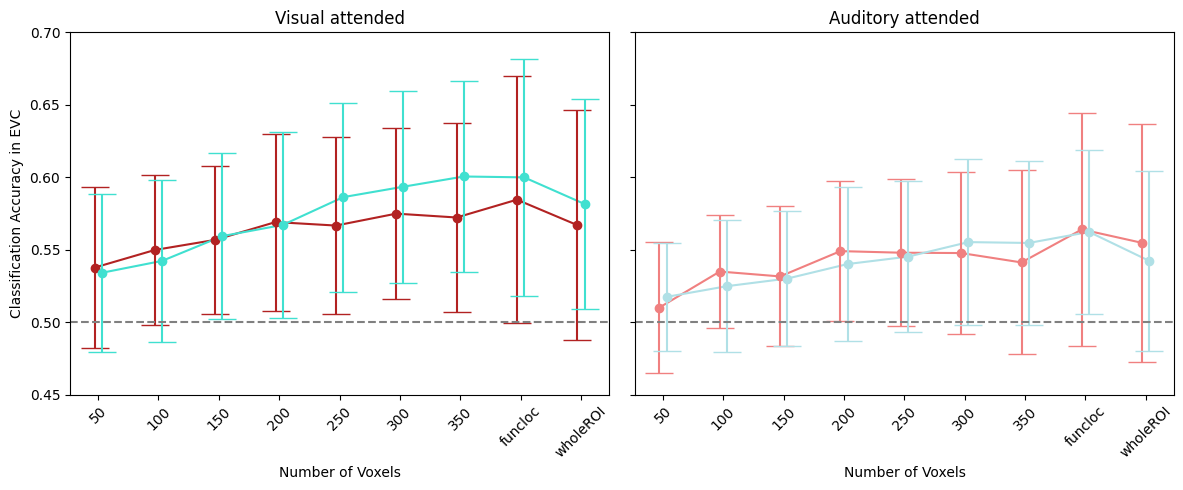

In [ ]:
n_voxels_list = [
    "50",
    "100",
    "150",
    "200",
    "250",
    "300",
    "350",
    "funcloc",
    "wholeROI",
]
df_allROIs = plot_decoding_nvoxels(DATA_PATH, n_voxels_list, ROI, "v_pred", save_fig=False)

## Analyze specific ROIs

In [3]:
ROI = "EVC"
n_voxels = "wholeROI"
df = pd.read_csv(f"{DATA_PATH}/{ROI}_{n_voxels}/balanced_group_data.csv")
df_grouped = df.groupby(["subj", "modality", "a_pred", "v_pred"], as_index=False)[
    "correct"
].mean()

### Attention * visual prediction

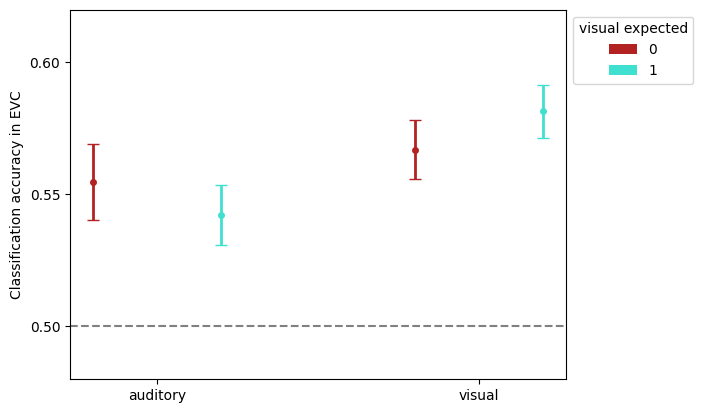

In [4]:
y = "correct"
x = "modality"
hue = "v_pred"
id = "subj"
dat = df.copy().groupby([id, x, hue], as_index=False)[y].mean()
barplot_morey(dat, x, y, hue, "visual expected", ["firebrick", "turquoise"], ["lightcoral", "powderblue"], False, False, False)
plt.xticks([0, 1], ["auditory", "visual"])
plt.ylabel(f"Classification accuracy in EVC")
plt.ylim(0.48, 0.62)
plt.yticks([0.5, 0.55, 0.6])
plt.axhline(0.5, color="grey", linestyle="--")

In [5]:
pg.rm_anova(dv=y, within=[x, hue], subject=id, data=dat.copy())

/media/wiseman/tocho/multipred-fmri/.venv/lib/python3.10/site-packages/pingouin/distribution.py:507: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  data.groupby(level=1, axis=1, observed=True, group_keys=False)
/media/wiseman/tocho/multipred-fmri/.venv/lib/python3.10/site-packages/pingouin/distribution.py:507: FutureWarning: DataFrameGroupBy.diff with axis=1 is deprecated and will be removed in a future version. Operate on the un-grouped DataFrame instead
  data.groupby(level=1, axis=1, observed=True, group_keys=False)


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps
0,modality,0.016646,1,24,0.016646,3.641609,0.068384,0.068384,0.020902,1.0
1,v_pred,0.000027,1,24,0.000027,0.007283,0.932700,0.932700,0.000035,1.0
2,modality * v_pred,0.004576,1,24,0.004576,1.915736,0.179064,0.179064,0.005834,1.0


In [6]:
pg.pairwise_tests(dv=y, within=[x, hue], subject=id, data=dat, padjust="fdr_bh")

,Contrast,modality,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges
0,modality,-,auditory,visual,True,True,-1.908300,24.0,two-sided,0.068384,NaN,NaN,1.003,-0.312604
1,v_pred,-,0,1,True,True,-0.085338,24.0,two-sided,0.932700,NaN,NaN,0.212,-0.012783
2,modality * v_pred,auditory,0,1,True,True,0.691789,24.0,two-sided,0.495709,0.495709,fdr_bh,0.262,0.139654
3,modality * v_pred,visual,0,1,True,True,-1.149297,24.0,two-sided,0.261759,0.495709,fdr_bh,0.381,-0.155577


### Multimodal analyses

/media/wiseman/tocho/multipred-fmri/.venv/lib/python3.10/site-packages/pingouin/distribution.py:507: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  data.groupby(level=1, axis=1, observed=True, group_keys=False)
/media/wiseman/tocho/multipred-fmri/.venv/lib/python3.10/site-packages/pingouin/distribution.py:507: FutureWarning: DataFrameGroupBy.diff with axis=1 is deprecated and will be removed in a future version. Operate on the un-grouped DataFrame instead
  data.groupby(level=1, axis=1, observed=True, group_keys=False)
/media/wiseman/tocho/multipred-fmri/multipred/plotting.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dat['subject_mean'] = dat.groupby('subj')[y].transform('mean

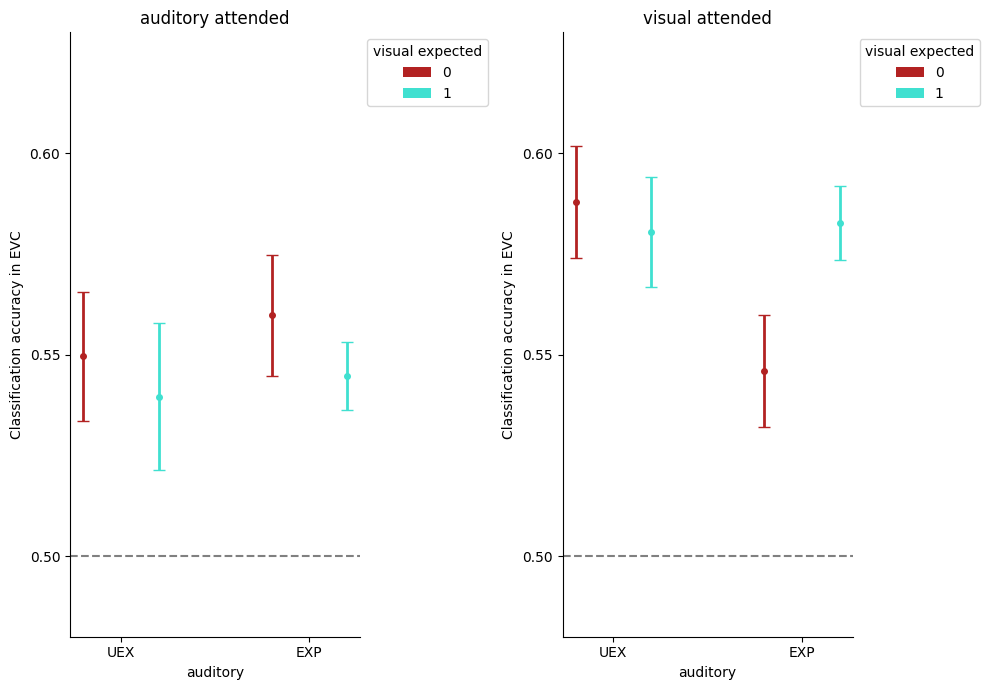

In [7]:
y = "correct"
x = "a_pred"
hue = "v_pred"
id = "subj"
ROI = "EVC"
save_fig = True
ylim = (0.48, 0.63)
yticks = [0.5, 0.55, 0.6]

anova_df, posthoc_df = analyze_attention_ROI(
    df_grouped, y, x, hue, "visual expected", id, ROI, save_fig, ylim, yticks
)

In [10]:
anova_df

,level_0,level_1,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps
0,auditory attended,0,a_pred,0.001479,1,24,0.001479,0.314679,0.580023,0.580023,0.001558,1.0
1,auditory attended,1,v_pred,0.003901,1,24,0.003901,0.478572,0.495709,0.495709,0.004098,1.0
2,auditory attended,2,a_pred * v_pred,0.000151,1,24,0.000151,0.039851,0.843453,0.843453,0.000159,1.0
3,visual attended,0,a_pred,0.009752,1,24,0.009752,2.403802,0.134128,0.134128,0.009532,1.0
4,visual attended,1,v_pred,0.005305,1,24,0.005305,1.320884,0.261759,0.261759,0.005208,1.0
5,visual attended,2,a_pred * v_pred,0.012192,1,24,0.012192,2.911054,0.100884,0.100884,0.011890,1.0


In [11]:
posthoc_df

,level_0,level_1,Contrast,a_pred,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges
0,auditory attended,0,a_pred,-,0,1,True,True,-0.560963,24.0,two-sided,0.580023,NaN,NaN,0.243,-0.091217
1,auditory attended,1,v_pred,-,0,1,True,True,0.691789,24.0,two-sided,0.495709,NaN,NaN,0.262,0.139654
2,auditory attended,2,a_pred * v_pred,0,0,1,True,True,0.380307,24.0,two-sided,0.707062,0.707062,fdr_bh,0.225,0.086827
3,auditory attended,3,a_pred * v_pred,1,0,1,True,True,0.928247,24.0,two-sided,0.362522,0.707062,fdr_bh,0.311,0.178293
4,visual attended,0,a_pred,-,0,1,True,True,1.550420,24.0,two-sided,0.134128,NaN,NaN,0.604,0.210811
5,visual attended,1,v_pred,-,0,1,True,True,-1.149297,24.0,two-sided,0.261759,NaN,NaN,0.381,-0.155577
6,visual attended,2,a_pred * v_pred,0,0,1,True,True,0.373884,24.0,two-sided,0.711773,0.711773,fdr_bh,0.225,0.065161
7,visual attended,3,a_pred * v_pred,1,0,1,True,True,-2.308045,24.0,two-sided,0.029927,0.059854,fdr_bh,1.932,-0.397968
